### Homework4
#### Guo Tianyue
Refer to some ways of language grammar in ChatGpt.

#### Q1

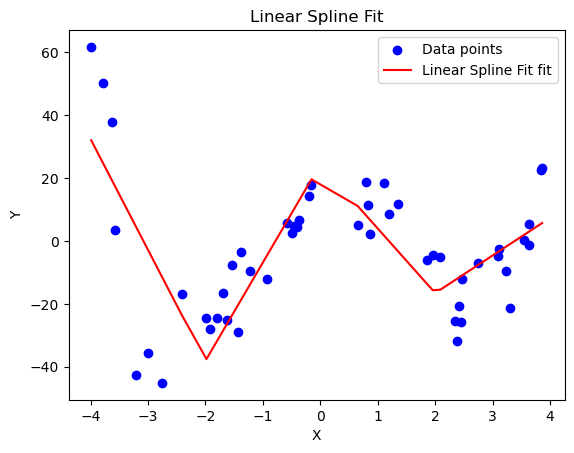

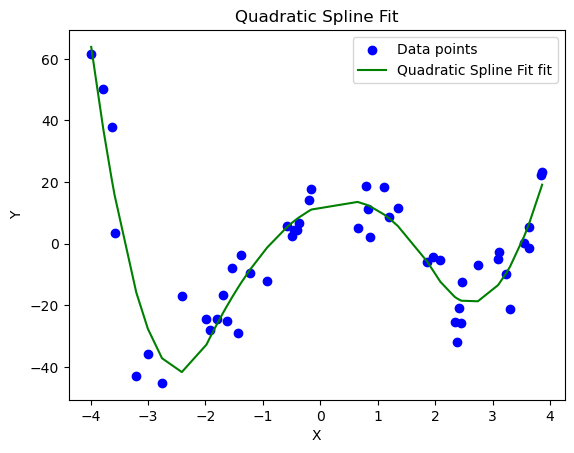

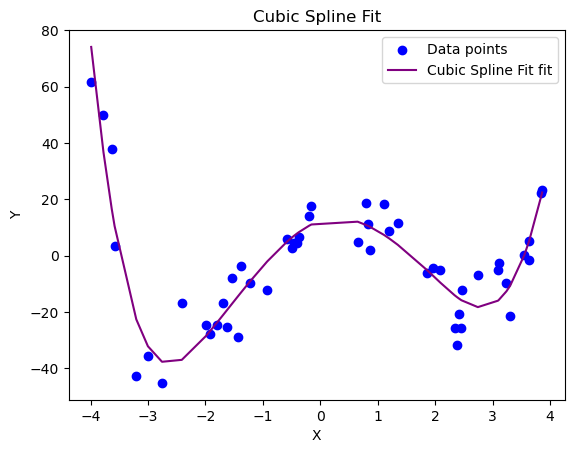

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
data = np.loadtxt('hw4_sample.txt')
X = data[:, 0]
Y = data[:, 1]

# Define basis functions
def linear_basis(x):
    return np.column_stack((np.ones_like(x), x, np.maximum(0, x + 2), np.maximum(0, x), np.maximum(0, x - 2)))

def quadratic_basis(x):
    return np.column_stack((np.ones_like(x), x, x**2, np.maximum(0, x + 2)**2, np.maximum(0, x)**2, np.maximum(0, x - 2)**2))

def cubic_basis(x):
    return np.column_stack((np.ones_like(x), x, x**2, x**3, np.maximum(0, x + 2)**3, np.maximum(0, x)**3, np.maximum(0, x - 2)**3))

# Linear least squares fitting
def fit_spline(X, Y, basis_function):
    B = basis_function(X)
    coefficients = np.linalg.lstsq(B, Y, rcond=None)[0]
    return coefficients

# Smooth plotting
def plot_fitted_curve(X, Y, coefficients, basis_function, title, color):
    X_sorted = np.sort(X)  # Sort X values for a smooth line
    B_sorted = basis_function(X_sorted)
    Y_fit_sorted = B_sorted @ coefficients  # Calculate fitted values

    plt.figure()
    plt.scatter(X, Y, color='blue', label='Data points')
    plt.plot(X_sorted, Y_fit_sorted, color=color, label=f'{title} fit')
    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.show()

# Fit and plot for Linear Splines
coefficients_linear = fit_spline(X, Y, linear_basis)
plot_fitted_curve(X, Y, coefficients_linear, linear_basis, 'Linear Spline Fit', 'red')

# Fit and plot for Quadratic Splines
coefficients_quadratic = fit_spline(X, Y, quadratic_basis)
plot_fitted_curve(X, Y, coefficients_quadratic, quadratic_basis, 'Quadratic Spline Fit', 'green')

# Fit and plot for Cubic Splines
coefficients_cubic = fit_spline(X, Y, cubic_basis)
plot_fitted_curve(X, Y, coefficients_cubic, cubic_basis, 'Cubic Spline Fit', 'purple')


#### Q2

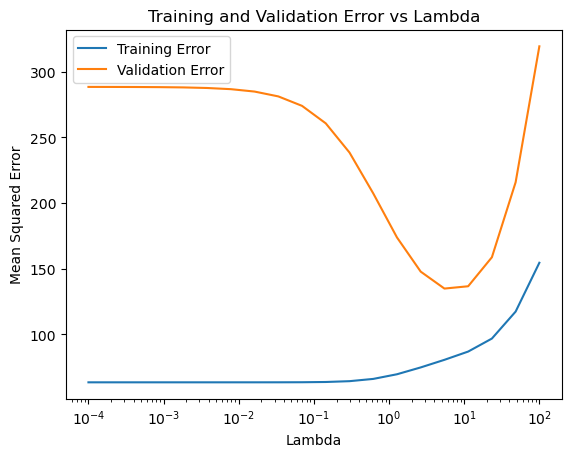

Best lambda: 5.455594781168514


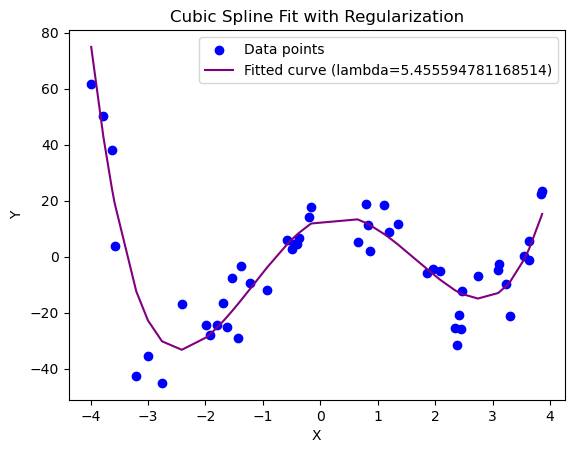

In [5]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# Define cubic spline basis function with regularization
def cubic_basis_with_regularization(x):
    return np.column_stack((np.ones_like(x), x, x**2, x**3, np.maximum(0, x + 2)**3, np.maximum(0, x)**3, np.maximum(0, x - 2)**3))

# Function to perform ridge regression with regularization on the cubic terms
def ridge_regression(X_train, Y_train, basis_function, lambd):
    B_train = basis_function(X_train)
    # Regularize only the cubic spline terms
    regularization_matrix = np.diag([0, 0, 0, 0, lambd, lambd, lambd])
    coefficients = np.linalg.inv(B_train.T @ B_train + regularization_matrix) @ B_train.T @ Y_train
    return coefficients

# Calculate mean squared error
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Split data into training and validation sets
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=0)

# Try different lambda values
lambdas = np.logspace(-4, 2, 20)
train_errors = []
val_errors = []

for lambd in lambdas:
    coefficients = ridge_regression(X_train, Y_train, cubic_basis_with_regularization, lambd)
    # Calculate training and validation errors
    train_pred = cubic_basis_with_regularization(X_train) @ coefficients
    val_pred = cubic_basis_with_regularization(X_val) @ coefficients
    train_errors.append(mse(Y_train, train_pred))
    val_errors.append(mse(Y_val, val_pred))

# Plot training and validation errors as a function of lambda
plt.figure()
plt.plot(lambdas, train_errors, label='Training Error')
plt.plot(lambdas, val_errors, label='Validation Error')
plt.xlabel('Lambda')
plt.ylabel('Mean Squared Error')
plt.xscale('log')
plt.title('Training and Validation Error vs Lambda')
plt.legend()
plt.show()

# Find the best lambda (minimizing validation error)
best_lambda = lambdas[np.argmin(val_errors)]
print(f"Best lambda: {best_lambda}")

# Fit the model with the best lambda and plot the fitted curve
best_coefficients = ridge_regression(X_train, Y_train, cubic_basis_with_regularization, best_lambda)

# Generate a smooth fitted curve
X_sorted = np.sort(X)
Y_fit_sorted = cubic_basis_with_regularization(X_sorted) @ best_coefficients

plt.figure()
plt.scatter(X, Y, color='blue', label='Data points')
plt.plot(X_sorted, Y_fit_sorted, color='purple', label=f'Fitted curve (lambda={best_lambda})')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Cubic Spline Fit with Regularization')
plt.legend()
plt.show()


#### Q3

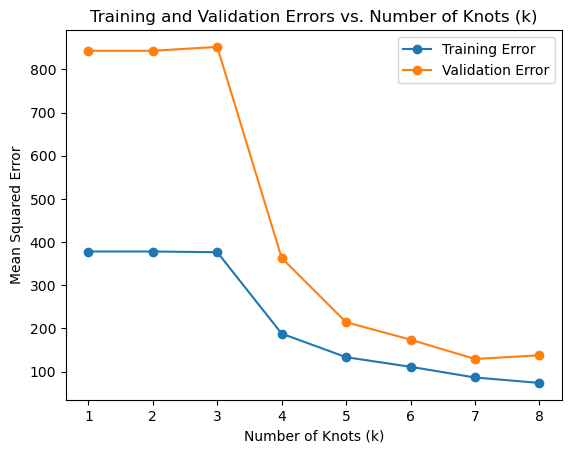

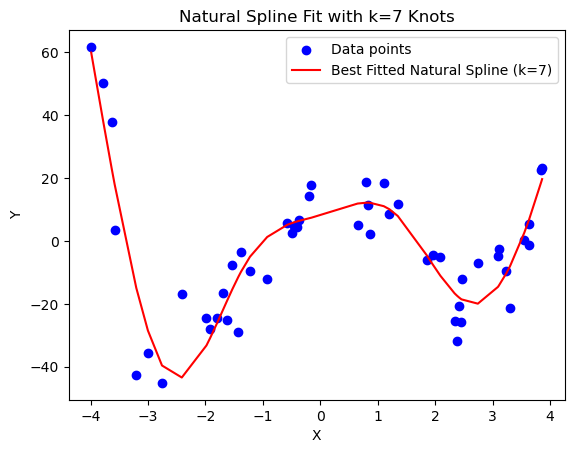

In [6]:

# Define natural spline basis with evenly spaced knots
def natural_spline_basis(x, knots):
    basis = [np.ones_like(x), x]  # Start with constant and linear terms
    for knot in knots:
        basis.append(np.maximum(0, x - knot) ** 3)  # Only add cubic term for positive (x - knot)
    return np.column_stack(basis)

# Split data into training and validation sets
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=0)

# Range of k values to test
k_values = range(1, 9)
train_errors = []
val_errors = []

# Cross-validation for different k
for k in k_values:
    # Define knots for natural spline (k evenly spaced between -4 and 4)
    knots = np.linspace(-4, 4, k)
    
    # Generate basis matrix for training and validation sets
    B_train = natural_spline_basis(X_train, knots)
    B_val = natural_spline_basis(X_val, knots)
    
    # Linear least squares fitting (without regularization)
    coefficients = np.linalg.lstsq(B_train, Y_train, rcond=None)[0]
    
    # Calculate training and validation predictions
    Y_train_pred = B_train @ coefficients
    Y_val_pred = B_val @ coefficients
    
    # Calculate training and validation MSE
    train_errors.append(np.mean((Y_train - Y_train_pred) ** 2))
    val_errors.append(np.mean((Y_val - Y_val_pred) ** 2))

# Plot training and validation errors as a function of k
plt.figure()
plt.plot(k_values, train_errors, label='Training Error', marker='o')
plt.plot(k_values, val_errors, label='Validation Error', marker='o')
plt.xlabel('Number of Knots (k)')
plt.ylabel('Mean Squared Error')
plt.title('Training and Validation Errors vs. Number of Knots (k)')
plt.legend()
plt.show()

# Find the best k (minimizing validation error)
best_k = k_values[np.argmin(val_errors)]
best_knots = np.linspace(-4, 4, best_k)

# Fit the model using the best k
B_best = natural_spline_basis(X, best_knots)
best_coefficients = np.linalg.lstsq(B_best, Y, rcond=None)[0]

# Generate smooth fitted curve
X_sorted = np.sort(X)
B_sorted = natural_spline_basis(X_sorted, best_knots)
Y_fit_sorted = B_sorted @ best_coefficients

# Plot the dataset and fitted curve
plt.figure()
plt.scatter(X, Y, color='blue', label='Data points')
plt.plot(X_sorted, Y_fit_sorted, color='red', label=f'Best Fitted Natural Spline (k={best_k})')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Natural Spline Fit with k={best_k} Knots')
plt.legend()
plt.show()
